# Chapter 6: The True Static Split (Train / Val / Test) & Hyperparameter Grid

This notebook implements the gold-standard Chronological Static Split (1500 days Train / 500 days Val / 500 days Test).
It loops through a grid of Neural Network configurations (architectures and learning rates). 
The model that achieves the lowest NLL on the Validation Set is selected as the winner. 
Finally, the winning NN and the Baseline are evaluated purely on the Out-Of-Sample Test Set.

In [12]:
import warnings
warnings.filterwarnings('ignore')

import sys

from datetime import date
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t

from density_forecasting.evaluation.metrics import block_ks_test
from density_forecasting.evaluation.metrics import evaluate_forecasts, kupiec_pof_test
from density_forecasting.models.neural_networks import generate_montecarlo

# Import our optimized pipeline functions
from density_forecasting.evaluation.fast_pipeline import (
    read_data_features,
    extract_array,
    extract_df_nn,
    run_baseline,
    backtesting_baseline,
    initializate_nn_model,
    run_neural_networks,
    backtesting_neural_networks
)

# import warnings
# warnings.filterwarnings('ignore')

# import sys
# sys.path.append('..')
# import os

# from datetime import date
# import pandas as pd
# import numpy as np
# import tensorflow as tf
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.stats import t

# from src.evaluation.metrics import block_ks_test, evaluate_forecasts, kupiec_pof_test
# from src.models.neural_networks import generate_montecarlo

# # Import optimized pipeline functions
# from src.evaluation.fast_pipeline import (
#     read_data_features, extract_array, extract_df_nn, run_baseline,
#     backtesting_baseline, initializate_nn_model, run_neural_networks,
#     backtesting_neural_networks
# )


## 1. Configuration & Tuning Grid

In [13]:
# tickers = ['ARKK', 'USO', 'BTC-USD', 'SQM-B.SN', 'SPY', "TSLA", "DBK.DE"]
tickers = ['ARKK', 'USO', 'SQM-B.SN', 'SPY', "TSLA", "DBK.DE"]

# tickers = ["SPY", "TSLA", "DBK.DE"]
# start_date = date(2010, 1, 1) # Earlier start date to get more data
start_date = date(2014, 4, 30) # Earlier start date to get more data
end_date = date(2026, 4, 30)

# columns_deep = ['vix_ratio', 'VIX']
columns_linear = ['Feat_Realized_Vol_20', 'returns_m1', 'Feat_Momentum_20', 'returns_m1_std_st', 'returns_m1_kurt']
columns_deep = ['vix_ratio']


# columns_deep = ['vix_ratio', 'Feat_Volume_Shock', 'Feat_RSI_14']
# columns_linear = ['ret_1_mean', 'ret_1_std', 'ret_1_kurt', 'ret_1_skew', 'ret_1_mean_st', 'ret_1_std_st', 'vix_ratio', 'VIX']
# columns_deep = ['vix_ratio']

initial_epochs = 4001
MIN_DATA_ROWS = 2500 # 1500 Train, 500 Val, 500 Test = approx 10 years

# Hyperparameter Grid
grid_columns_deep = [['vix_ratio'], ['vix_ratio', 'Feat_Volume_Shock'], ['vix_ratio', 'Feat_RSI_14'], ['vix_ratio', 'Feat_Volume_Shock', 'Feat_RSI_14']]
grid_columns_linear = [['Feat_Realized_Vol_20', 'returns_m1', 'Feat_Momentum_20', 'returns_m1_std_st', 'returns_m1_kurt'], 
                       ['returns_m1', 'Feat_Momentum_20', 'returns_m1_std_st', 'returns_m1_kurt'], 
                       ['Feat_Realized_Vol_20', 'Feat_Momentum_20', 'returns_m1_std_st', 'returns_m1_kurt'],
                       ['Feat_Realized_Vol_20', 'returns_m1', 'returns_m1_std_st', 'returns_m1_kurt'],
                       ['Feat_Realized_Vol_20', 'returns_m1', 'Feat_Momentum_20', 'returns_m1_kurt'],
                       ['Feat_Realized_Vol_20', 'returns_m1', 'Feat_Momentum_20', 'returns_m1_std_st']
                       ]

# grid_model_classes = ['Linear', 'WideAndDeep']
grid_model_classes = ['WideAndDeep']
grid_lrs = [0.015]
# grid_lrs = [0.015, 0.005]

table_results = []



STATIC SPLIT SHOWDOWN & TUNING: ARKK
Fetching ARKK data...
Fetching VIX data...
Data Split -> Train: 1653 | Val: 551 | Test: 552

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: vix_ratio / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt)

-> Running Baseline (VIX-Scaled Student-T)
          Achieved Best Val NLL: 11.8938
   [Grid] Testing: vix_ratio / returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt)

-> Running Baseline (VIX-Scaled Student-T)
          Achieved Best Val NLL: 11.7817
   [Grid] Testing: vix_ratio / Feat_Realized_Vol_20-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt)

-> Running Baseline (VIX-Scaled Student-T)
          Achieved Best Val NLL: 11.8651
   [Grid] Testing: vix_ratio / Feat_Realized_Vol_20-returns_m1-returns_m1_std_st-returns_m1_kurt)

-> Running Baseline (VIX-Scaled Student-T)
          Achieved Best Val NLL: 11.7922
   [Grid] Testing: vix_ratio / Feat_Realized_Vol_20-returns_m1-Feat_Mome

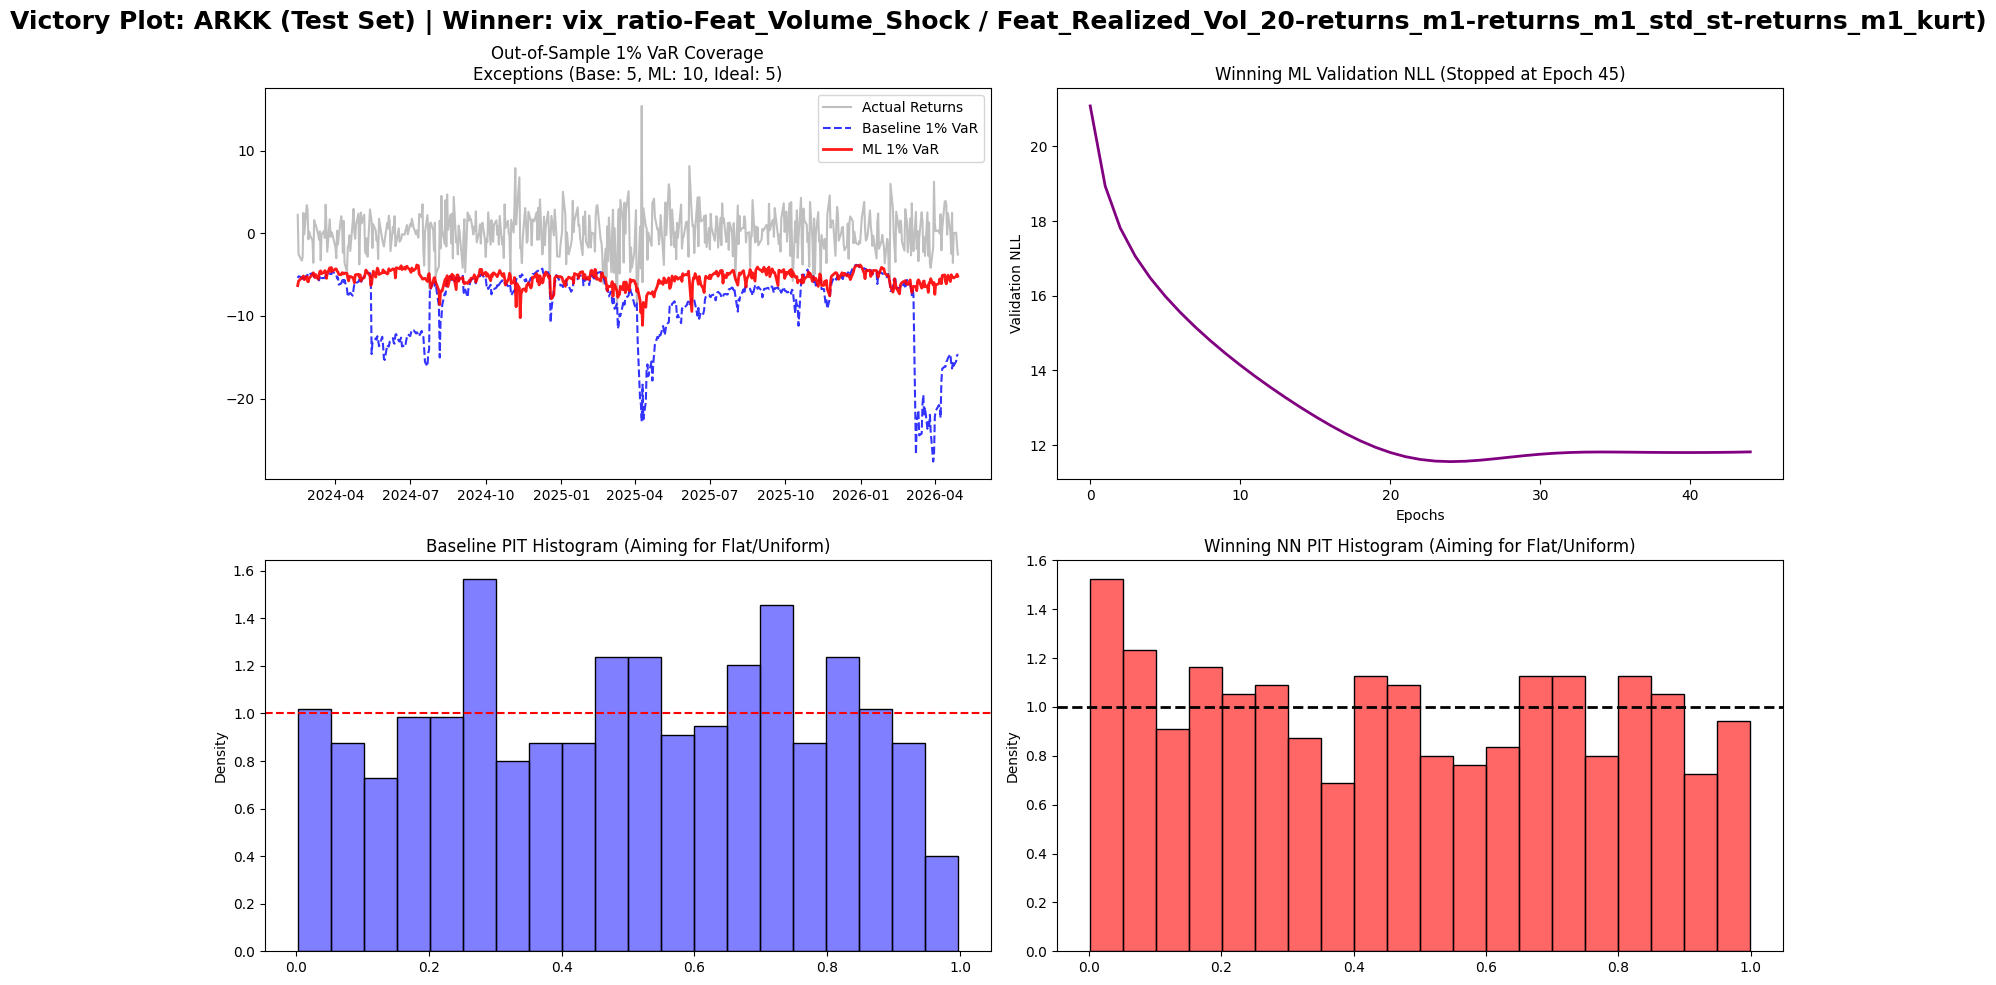


STATIC SPLIT SHOWDOWN & TUNING: USO
Fetching USO data...
Fetching VIX data...
Data Split -> Train: 1731 | Val: 577 | Test: 577

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: vix_ratio / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt)

-> Running Baseline (VIX-Scaled Student-T)
          Achieved Best Val NLL: 8.3072
   [Grid] Testing: vix_ratio / returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt)

-> Running Baseline (VIX-Scaled Student-T)
          Achieved Best Val NLL: 8.2867
   [Grid] Testing: vix_ratio / Feat_Realized_Vol_20-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt)

-> Running Baseline (VIX-Scaled Student-T)
          Achieved Best Val NLL: 8.3050
   [Grid] Testing: vix_ratio / Feat_Realized_Vol_20-returns_m1-returns_m1_std_st-returns_m1_kurt)

-> Running Baseline (VIX-Scaled Student-T)
          Achieved Best Val NLL: 8.2419
   [Grid] Testing: vix_ratio / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_2

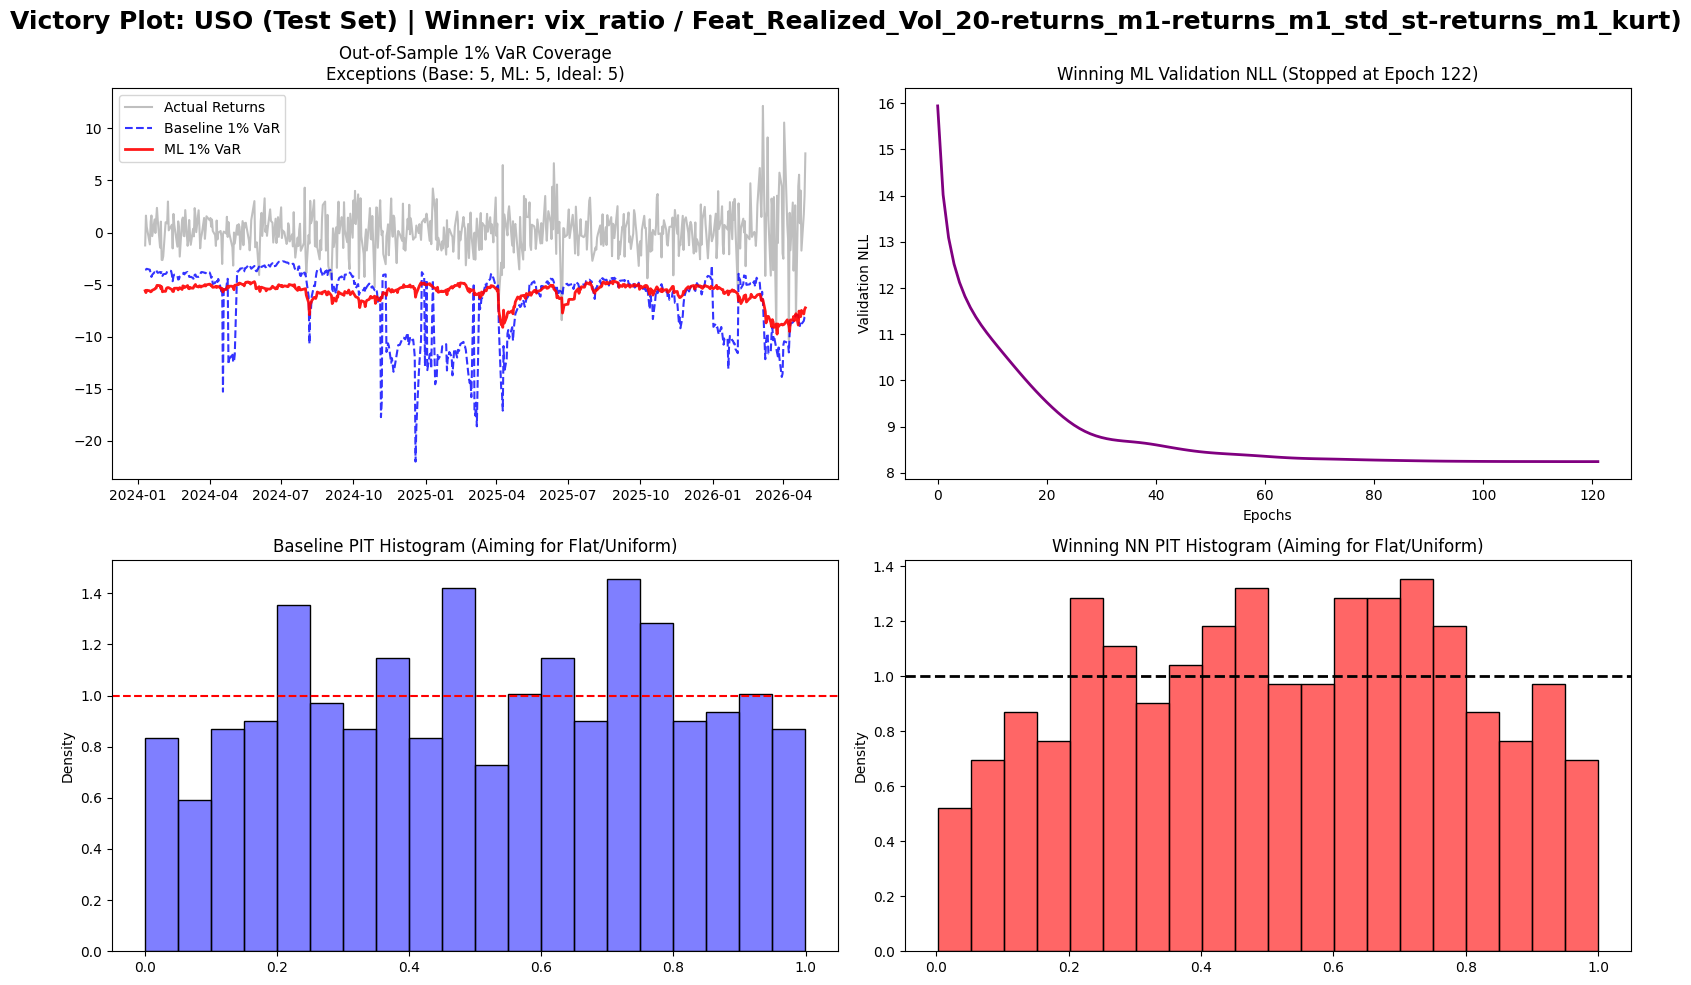


STATIC SPLIT SHOWDOWN & TUNING: SQM-B.SN
Fetching SQM-B.SN data...
Fetching VIX data...
Data Split -> Train: 1775 | Val: 591 | Test: 593

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: vix_ratio / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt)

-> Running Baseline (VIX-Scaled Student-T)
          Achieved Best Val NLL: 8.2525
   [Grid] Testing: vix_ratio / returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt)

-> Running Baseline (VIX-Scaled Student-T)
          Achieved Best Val NLL: 8.2677
   [Grid] Testing: vix_ratio / Feat_Realized_Vol_20-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt)

-> Running Baseline (VIX-Scaled Student-T)
          Achieved Best Val NLL: 8.2654
   [Grid] Testing: vix_ratio / Feat_Realized_Vol_20-returns_m1-returns_m1_std_st-returns_m1_kurt)

-> Running Baseline (VIX-Scaled Student-T)
          Achieved Best Val NLL: 8.2914
   [Grid] Testing: vix_ratio / Feat_Realized_Vol_20-returns_m1-Feat_

In [ ]:
for ticker in tickers:
    print(f"\n{'='*60}")
    print(f"STATIC SPLIT SHOWDOWN & TUNING: {ticker}")
    print(f"{'='*60}")
    
    # 1. Fetch Data
    df_features = read_data_features(ticker, start_date, end_date)
    
    if len(df_features) < MIN_DATA_ROWS:
        print(f"⚠️ Skipping {ticker}: Only {len(df_features)} days available. Need at least {MIN_DATA_ROWS} for robust splits.")
        continue
        
    # 2. Strict Chronological Split
    n_train = int(0.6 * len(df_features))
    n_val = int(0.2 * len(df_features))
    # Use whatever is left for test, minimum 500
    n_test = len(df_features) - n_train - n_val 
    
    print(f"Data Split -> Train: {n_train} | Val: {n_val} | Test: {n_test}")
    
    df_train = df_features.iloc[:n_train]
    df_val = df_features.iloc[n_train:n_train+n_val]
    df_test = df_features.iloc[n_train+n_val:]
    
    # =========================================================
    # NEURAL NETWORK TUNING
    # =========================================================
    print("\n-> Running Neural Network Hyperparameter Grid")
    best_val_loss_overall = np.inf
    best_model = None
    best_config_name = ""
    best_val_loss_history = []
    
    m_class = 'WideAndDeep'
    lr = 0.015
    # for m_class in grid_model_classes:
    for columns_deep in grid_columns_deep:
        for columns_linear in grid_columns_linear:
            
            config_name = f"{'-'.join(columns_deep)} / {'-'.join(columns_linear)})"
            print(f"   [Grid] Testing: {config_name}")

            # Extract NN Tensors
            X_lin_tr, X_deep_tr, y_tr = extract_df_nn(df_train, columns_linear, columns_deep)
            X_lin_v, X_deep_v, y_v = extract_df_nn(df_val, columns_linear, columns_deep)
            X_lin_te, X_deep_te, y_te = extract_df_nn(df_test, columns_linear, columns_deep)
            
            # Extract Arrays for Baseline
            data_train = extract_array(df_train, y_tr)
            data_val = extract_array(df_val, y_v)

            data_test = extract_array(df_test, y_te)
            
            # =========================================================
            # BASELINE MODEL
            # =========================================================
            print("\n-> Running Baseline (VIX-Scaled Student-T)")
            optimal_beta = run_baseline(data_train, last_optimal_beta=0.5, cold_start=True)
            baseline_results = backtesting_baseline(data_test, optimal_beta)
            
            baseline_prior_v = backtesting_baseline(data_val, optimal_beta)
            # print(f"len(baseline_prior[mu]) {len(baseline_prior['mu'])}")
            prior_data_v = {'mu': baseline_prior_v['mu'], 'sigma': baseline_prior_v['sigma'], 'nu': baseline_prior_v['nu']}

            baseline_prior_train = backtesting_baseline(data_train, optimal_beta)
            # print(f"len(baseline_prior[mu]) {len(baseline_prior['mu'])}")
            prior_data_tr = {'mu': baseline_prior_train['mu'], 'sigma': baseline_prior_train['sigma'], 'nu': baseline_prior_train['nu']}

            # data_test = extract_array(df_test, y_te)
            # baseline_results = backtesting_baseline(data_test, optimal_beta)
            
            train_step, val_step, model = initializate_nn_model(columns_linear, m_class, lr, columns_deep=columns_deep)
            
            val_loss_history = run_neural_networks(
                X_lin_tr, X_deep_tr, y_tr,
                X_lin_v, X_deep_v, y_v,
                initial_epochs, train_step, val_step, model, prior_data_train=prior_data_tr, prior_data_v=prior_data_v, verbose=False
            )
            
            min_val = min(val_loss_history)
            print(f"          Achieved Best Val NLL: {min_val:.4f}")
            
            if min_val < best_val_loss_overall:
                best_val_loss_overall = min_val
                best_model = model
                best_config_name = config_name
                best_val_loss_history = val_loss_history
                best_columns_deep = columns_deep
                best_columns_linear = columns_linear
                    
    print(f"\n🏆 WINNING CONFIGURATION: {best_config_name} with Val NLL = {best_val_loss_overall:.4f}")
    
        # Re-extract the winning deep test features!
    _, X_deep_te_winning, _ = extract_df_nn(df_test, best_columns_linear, best_columns_deep)

    # Evaluate Winning Model on Test Set
    nn_results = backtesting_neural_networks(
        tf.convert_to_tensor(X_lin_te.to_numpy(), dtype=tf.float32), 
        tf.convert_to_tensor(X_deep_te_winning.to_numpy(), dtype=tf.float32) if X_deep_te_winning is not None else None, 
        tf.convert_to_tensor(y_te.to_numpy(), dtype=tf.float32), 
        best_model
    )

    # # Evaluate Winning Model on Test Set
    # nn_results = backtesting_neural_networks(
    #     tf.convert_to_tensor(X_lin_te.to_numpy(), dtype=tf.float32), 
    #     tf.convert_to_tensor(X_deep_te.to_numpy(), dtype=tf.float32) if X_deep_te is not None else None, 
    #     tf.convert_to_tensor(y_te.to_numpy(), dtype=tf.float32), 
    #     best_model
    # )
    
    # =========================================================
    # METRICS EVALUATION
    # =========================================================
    actual_returns = y_te.values
    
    def calculate_metrics(results_dict, model_name):
        mu = results_dict['mu']
        sigma = results_dict['sigma']
        nu = results_dict['nu']
        pit = results_dict['pit_values']
        df_pit_total = pd.DataFrame(pit)
        df_ks = block_ks_test(df_pit_total, block_size=len(df_pit_total), alpha=0.05)
        pit_accept = df_ks['Status'].values[0]
        # pit_accept = (df_ks['Status'].values[0] != '❌ FAILED')


        # CRPS
        ensembles = generate_montecarlo(mu, sigma, nu, n_samples=1000)
        df_eval = evaluate_forecasts(y_te, ensembles)
        crps = df_eval['CRPS'].mean()
        nll = -df_eval['Log_Likelihood'].sum()
        
        # VaR 99% for Kupiec Test
        var_99 = t.ppf(0.01, df=nu, loc=mu, scale=sigma)
        kupiec = kupiec_pof_test(actual_returns, var_99, confidence_level=0.99)
        

        return crps, nll, kupiec, var_99, pit, pit_accept
        
    crps_base, nll_base, kupiec_base, var_base, pit_base, pit_accept_base = calculate_metrics(baseline_results, 'Baseline')
    crps_nn, nll_nn, kupiec_nn, var_nn, pit_nn, pit_accept_nn = calculate_metrics(nn_results, 'Neural-Network')
    
    table_results.append({
        'Ticker': ticker,
        'Winning_NN_Config': best_config_name,
        'NLL_Baseline': nll_base,
        'NLL_ML': nll_nn,
        'CRPS_Baseline': crps_base,
        'CRPS_ML': crps_nn,
        'Exceptions_Base': f"{kupiec_base['Exceptions']} / {int(kupiec_base['Expected'])}",
        'Exceptions_ML': f"{kupiec_nn['Exceptions']} / {int(kupiec_nn['Expected'])}",
        'Kupiec_Base_Status': kupiec_base['Status'],
        'Kupiec_ML_Status': kupiec_nn['Status'],
        'KS_PIT_Base_Result': pit_accept_base,
        'KS_PIT_ML_Result': pit_accept_nn
    })
    
    # =========================================================
    # VICTORY PLOTS
    # =========================================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"Victory Plot: {ticker} (Test Set) | Winner: {best_config_name}", fontsize=18, fontweight='bold')
    
    # Plot 1: 1% VaR Exceedance Coverage
    dates_test = df_test.index
    axes[0, 0].plot(dates_test, actual_returns, label='Actual Returns', color='gray', alpha=0.5)
    axes[0, 0].plot(dates_test, var_base, label='Baseline 1% VaR', color='blue', alpha=0.8, linestyle='--')
    axes[0, 0].plot(dates_test, var_nn, label='ML 1% VaR', color='red', alpha=0.9, linewidth=2)
    axes[0, 0].set_title(f"Out-of-Sample 1% VaR Coverage\nExceptions (Base: {kupiec_base['Exceptions']}, ML: {kupiec_nn['Exceptions']}, Ideal: {int(kupiec_nn['Expected'])})")
    axes[0, 0].legend()
    
    # Plot 2: Validation Loss Curve (Early Stopping)
    axes[0, 1].plot(best_val_loss_history, color='purple', linewidth=2)
    axes[0, 1].set_title(f"Winning ML Validation NLL (Stopped at Epoch {len(best_val_loss_history)})")
    axes[0, 1].set_xlabel("Epochs")
    axes[0, 1].set_ylabel("Validation NLL")
    
    # Plot 3: Baseline PIT Histogram
    sns.histplot(pit_base, bins=20, color='blue', alpha=0.5, stat='density', ax=axes[1, 0])
    axes[1, 0].axhline(1.0, color='red', linestyle='--')
    axes[1, 0].set_title("Baseline PIT Histogram (Aiming for Flat/Uniform)")
    
    # Plot 4: ML PIT Histogram
    sns.histplot(pit_nn, bins=20, color='red', alpha=0.6, stat='density', ax=axes[1, 1])
    axes[1, 1].axhline(1.0, color='black', linestyle='--', linewidth=2)
    axes[1, 1].set_title("Winning NN PIT Histogram (Aiming for Flat/Uniform)")
    
    plt.tight_layout()
    plt.show()


## 2. Quantitative Summary & Export

In [ ]:
import os
df_res = pd.DataFrame(table_results)
if len(df_res) > 0:
    df_res.set_index('Ticker', inplace=True)
    df_res['NLL_Winner'] = np.where(df_res['NLL_ML'] < df_res['NLL_Baseline'], 'ML', 'Baseline')
    df_res['CRPS_Winner'] = np.where(df_res['CRPS_ML'] < df_res['CRPS_Baseline'], 'ML', 'Baseline')
    display(df_res)
    
    output_dir = '../outputs'
    os.makedirs(output_dir, exist_ok=True)
    
    # Re-order and export
    export_cols = ['Winning_NN_Config', 'NLL_Baseline', 'NLL_ML', 'NLL_Winner', 
                   'CRPS_Baseline', 'CRPS_ML', 'CRPS_Winner', 
                   'Exceptions_Base', 'Exceptions_ML', 'Kupiec_Base_Status', 'Kupiec_ML_Status']
    
    df_export = df_res[export_cols]
    df_export.to_csv(f'{output_dir}/showdown_results_static.csv')
    df_export.to_json(f'{output_dir}/showdown_results_static.json', orient='index')
    
    print(f'Results successfully saved to {output_dir}')
else:
    print("No valid results to display.")


,Winning_NN_Config,NLL_Baseline,NLL_ML,CRPS_Baseline,CRPS_ML,Exceptions_Base,Exceptions_ML,Kupiec_Base_Status,Kupiec_ML_Status,NLL_Winner,CRPS_Winner
Ticker,,,,,,,,,,,
ARKK,vix_ratio-Feat_Volume_Shock (lr=0.015),1292.918516,1270.086136,1.281555,1.058364,5 / 5,5 / 5,✅ PASSED,✅ PASSED,ML,ML
USO,vix_ratio (lr=0.015),1226.111065,1248.895785,1.130159,1.191587,5 / 5,5 / 5,✅ PASSED,✅ PASSED,Baseline,Baseline
BTC-USD,vix_ratio (lr=0.015),1924.963025,1992.361179,1.272983,1.266490,6 / 8,1 / 8,✅ PASSED,❌ FAILED,Baseline,ML
SQM-B.SN,vix_ratio (lr=0.015),1442.994680,1420.180246,1.461311,1.355069,3 / 5,7 / 5,✅ PASSED,✅ PASSED,ML,ML
SPY,vix_ratio-Feat_Volume_Shock (lr=0.015),719.410809,875.162700,0.418114,0.483180,9 / 5,2 / 5,✅ PASSED,✅ PASSED,Baseline,Baseline
TSLA,vix_ratio-Feat_Volume_Shock-Feat_RSI_14 (lr=0....,1585.324459,1570.901951,1.952145,1.832351,4 / 5,6 / 5,✅ PASSED,✅ PASSED,ML,ML
DBK.DE,vix_ratio-Feat_Volume_Shock (lr=0.015),1251.708417,1250.637390,0.917019,1.161225,6 / 5,8 / 5,✅ PASSED,✅ PASSED,ML,Baseline


Results successfully saved to ../outputs
